<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/lg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
!pip install uv
!uv pip install langchain-mistralai

Using Python 3.12.13 environment at: /usr
Checked 1 package in 81ms


In [96]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool
from typing import TypedDict
from operator import add
from typing import Annotated , List
from pydantic import BaseModel , Field

In [97]:
CHAT_MISTRAL_API_KEY = "USE YOUR KEY HERE "

In [98]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY,
    temperature = 0
)
print(llm.invoke("hello"))

AIMessage(
    content='Hello! 😊 How can I assist you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 4,
            'total_tokens': 17,
            'completion_tokens': 13,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f5107-4a3d-7052-a75a-9b484ed125ff-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}
)

In [99]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts:

{human_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [100]:
class Analyst(BaseModel):
  name : str = Field(description = "Name of the Analyst")
  affiliation : str = Field(description = "primary affiliation of the analyst")
  role : str = Field(description = "Role of the analyst in the context of the topic")
  description : str = Field(description = "Description of the analyst focus, concerns, and motives")

  @property
  def persona(self)->str:
    return f"Name : {self.name}\nRole {self.role}\nAffiliation : {self.affiliation}\n Description : {self.description}\n"

class Perspective(BaseModel):
  analyst : List[Analyst]= Field(description = "Comprehensive list of analysts with their roles and affiliations")

In [101]:
class OverallState(TypedDict):
  topic : str
  max_analyst : int
  human_feedback : str
  analyst : List[Analyst]

In [102]:
def analyst_creator(state : OverallState):
  max_analyst = state['max_analyst']
  topic = state['topic']
  human_feedback = state.get('human_feedback', '')
  prompt = analyst_instructions.format(topic = topic , human_feedback = human_feedback , max_analysts = max_analyst)

  structured_llm = llm.with_structured_output(Perspective)

  analyst = structured_llm.invoke([
      SystemMessage(content=prompt)
  ] + [HumanMessage(content='generate set of analysts')])

  return {'analyst':analyst.analyst}


In [103]:
def human_feedback():
  pass

In [104]:
def human_analyst_feedback(state : OverallState):
  human_feedback=state.get('human_feedback', None)
  if human_feedback:
    return "analyst_creator"
  else:
    return END

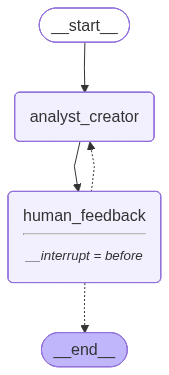

In [105]:
builder = StateGraph(OverallState)
builder.add_node("analyst_creator",analyst_creator)
builder.add_node("human_feedback",human_feedback)

builder.add_edge(START , "analyst_creator")
builder.add_edge("analyst_creator" , "human_feedback")
builder.add_conditional_edges("human_feedback",human_analyst_feedback , ['analyst_creator',END])

memory = MemorySaver()

graph = builder.compile(memory , interrupt_before = ['human_feedback'])

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [106]:
max_assistant = 3
topic = "why we require notebooks if we have laptops and tablets"
config = {'configurable':{'thread_id':2}}

for event in graph.stream({"topic":topic,"max_analyst":max_assistant},config ,
                          stream_mode="values"):
  print(event)

{'topic': 'why we require notebooks if we have laptops and tablets', 'max_analyst': 3}

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'analyst': [
        Analyst(
            name='Dr. Eleanor Hartwell',
            affiliation='Institute for Digital Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of digital tools. She is concerned 
with how notebooks can enhance learning experiences compared to laptops and tablets, emphasizing the tactile and 
cognitive benefits of handwriting and the role of notebooks in fostering creativity and critical thinking.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Workplace Design',
            role='Ergonomics Specialist',
            description='Marcus Chen examines the physical and psychological impacts of using different writing and
computing tools. He is interested in how notebooks can reduce screen time, minimize eye strain, and provide a more 
comfortable and flexible writing experience, which can lead to better focus and productivity.'
        ),
        Analyst(
            name='Sophia Rivera',
            affiliation='Center for Sustainable Technology',
            role='Sustainability Advocate',
            description='Sophia Rivera explores the environmental impact of digital devices versus traditional 
notebooks. She advocates for the use of notebooks as a more sustainable option, highlighting the e-waste problem 
associated with laptops and tablets, and promoting the longevity and recyclability of notebooks.'
        )
    ]
}

In [107]:
graph.get_state(config).next

('human_feedback',)

In [108]:
human_feedback = "Could you add more analyst from different fields also"
for event in graph.stream({"human_feedback":human_feedback},config ,
                          stream_mode="values"):
  print(event)

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'human_feedback': 'Could you add more analyst from different fields also',
    'analyst': [
        Analyst(
            name='Dr. Eleanor Hartwell',
            affiliation='Institute for Digital Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of digital tools. She is concerned 
with how notebooks can enhance learning experiences compared to laptops and tablets, emphasizing the tactile and 
cognitive benefits of handwriting and the role of notebooks in fostering creativity and critical thinking.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Workplace Design',
            role='Ergonomics Specialist',
            description='Marcus Chen examines the physical and psychological impacts of using different writing and
computing tools. He is interested in how notebooks can reduce screen time, minimize eye strain, and provide a more 
comfortable and flexible writing experience, which can lead to better focus and productivity.'
        ),
        Analyst(
            name='Sophia Rivera',
            affiliation='Center for Sustainable Technology',
            role='Sustainability Advocate',
            description='Sophia Rivera explores the environmental impact of digital devices versus traditional 
notebooks. She advocates for the use of notebooks as a more sustainable option, highlighting the e-waste problem 
associated with laptops and tablets, and promoting the longevity and recyclability of notebooks.'
        )
    ]
}

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'human_feedback': 'Could you add more analyst from different fields also',
    'analyst': [
        Analyst(
            name='Dr. Sarah Johnson',
            affiliation='Educational Technology Research Institute',
            role='Educational Technologist',
            description='Dr. Johnson focuses on the role of notebooks in educational settings. She is concerned 
with how notebooks facilitate learning and creativity in ways that laptops and tablets might not. Her research 
explores the tactile and cognitive benefits of handwriting and drawing, and she advocates for the integration of 
traditional and digital tools in education.'
        ),
        Analyst(
            name='Alex Chen',
            affiliation='Creative Industries Association',
            role='Industrial Designer',
            description='Alex Chen examines the design and ergonomic aspects of notebooks compared to laptops and 
tablets. He is interested in how the physical form of notebooks influences user experience and productivity. His 
work involves studying user behavior and designing innovative products that combine the best features of both 
traditional and digital note-taking tools.'
        ),
        Analyst(
            name='Prof. Emily Rodriguez',
            affiliation='Psychology Department, Urban University',
            role='Cognitive Psychologist',
            description='Prof. Rodriguez investigates the cognitive processes involved in note-taking and 
information retention. She is particularly interested in how the medium of note-taking (handwritten vs. digital) 
affects memory and comprehension. Her research aims to provide insights into optimal note-taking practices for 
different individuals and contexts.'
        )
    ]
}

In [109]:
graph.get_state(config).next

('human_feedback',)

In [110]:
further_feedback = None

In [111]:
graph.update_state(config,{"human_feedback":further_feedback},as_node = 'human_feedback')

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17d1f4-2c16-618f-8005-5160213d8289'}}

In [112]:
graph.get_state(config).next

()

In [113]:
for event in graph.stream(None,config ,
                          stream_mode="updates"):
  print(event)

In [115]:
print(graph.get_state(config).next)

()